# **UCI HAR - LSTM Classification**

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, BatchNormalization, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# Load Dataset

In [3]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/drive/MyDrive/AI_assignment/UCI_HAR_Dataset/"

In [4]:
# Load "X"
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []  # 한 센서축 데이터 전체 저장

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ') # 공백 2개를 1개로
                row_clean = row_clean.strip() # 양쪽 공백 제거
                serie = row_clean.split(' ') # 공백 기준 split
                serie_array = np.array(serie, dtype=np.float32) # float32 numpy 배열로 변환
                series_list.append(serie_array) # 시퀀스 추가

        # 하나의 센서축 데이터 추가 (feature)
        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)
    # shape 변환 → (샘플 수, 타임스텝 수, 특성 수)
    return np.transpose(X_signals, (1, 2, 0))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("첫 번째 샘플 데이터:\n", X_train[0])

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
첫 번째 샘플 데이터:
 [[ 1.808515e-04  1.076681e-02  5.556068e-02 ...  1.012817e+00
  -1.232167e-01  1.029341e-01]
 [ 1.013856e-02  6.579480e-03  5.512483e-02 ...  1.022833e+00
  -1.268756e-01  1.056872e-01]
 [ 9.275574e-03  8.928878e-03  4.840473e-02 ...  1.022028e+00
  -1.240037e-01  1.021025e-01]
 ...
 [-1.147484e-03  1.714439e-04  2.647864e-03 ...  1.018445e+00
  -1.240696e-01  1.003852e-01]
 [-2.222655e-04  1.574181e-03  2.381057e-03 ...  1.019372e+00
  -1.227451e-01  9.987355e-02]
 [ 1.575500e-03  3.070189e-03 -2.269757e-03 ...  1.021171e+00
  -1.213260e-01  9.498741e-02]]


In [5]:
# Load "y"

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    # 라벨을 0부터 시작하도록 -1 (원래 라벨이 1부터 시)
    return np.array(labels, dtype=np.int32) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print(y_train[:5])

y_train shape: (7352,)
y_test shape: (2947,)
[4 4 4 4 4]


# 모델 생성
- Layer : LSTM층 2개 + Dense층 2개

In [6]:
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = 6

optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model = Sequential([
            Input(shape=input_shape),

            # 첫번째 LSTM층
            LSTM(256, return_sequences=True),
            BatchNormalization(),

            # 두번째 LSTM층
            LSTM(128, return_sequences=False, dropout=0.3),
            BatchNormalization(),

            # Dense층 2개
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dropout(0.4),
            Dense(num_classes, activation='softmax')
        ])

model.compile(
            optimizer=optimizer,
            loss='sparse_categorical_crossentropy',
            metrics=['sparse_categorical_accuracy']
        )

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128, 256)       │       272,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 479,942 (1.83 MB)

 Trainable params: 479,046 (1.83 MB)

 Non-trainable params: 896 (3.50 KB)

None


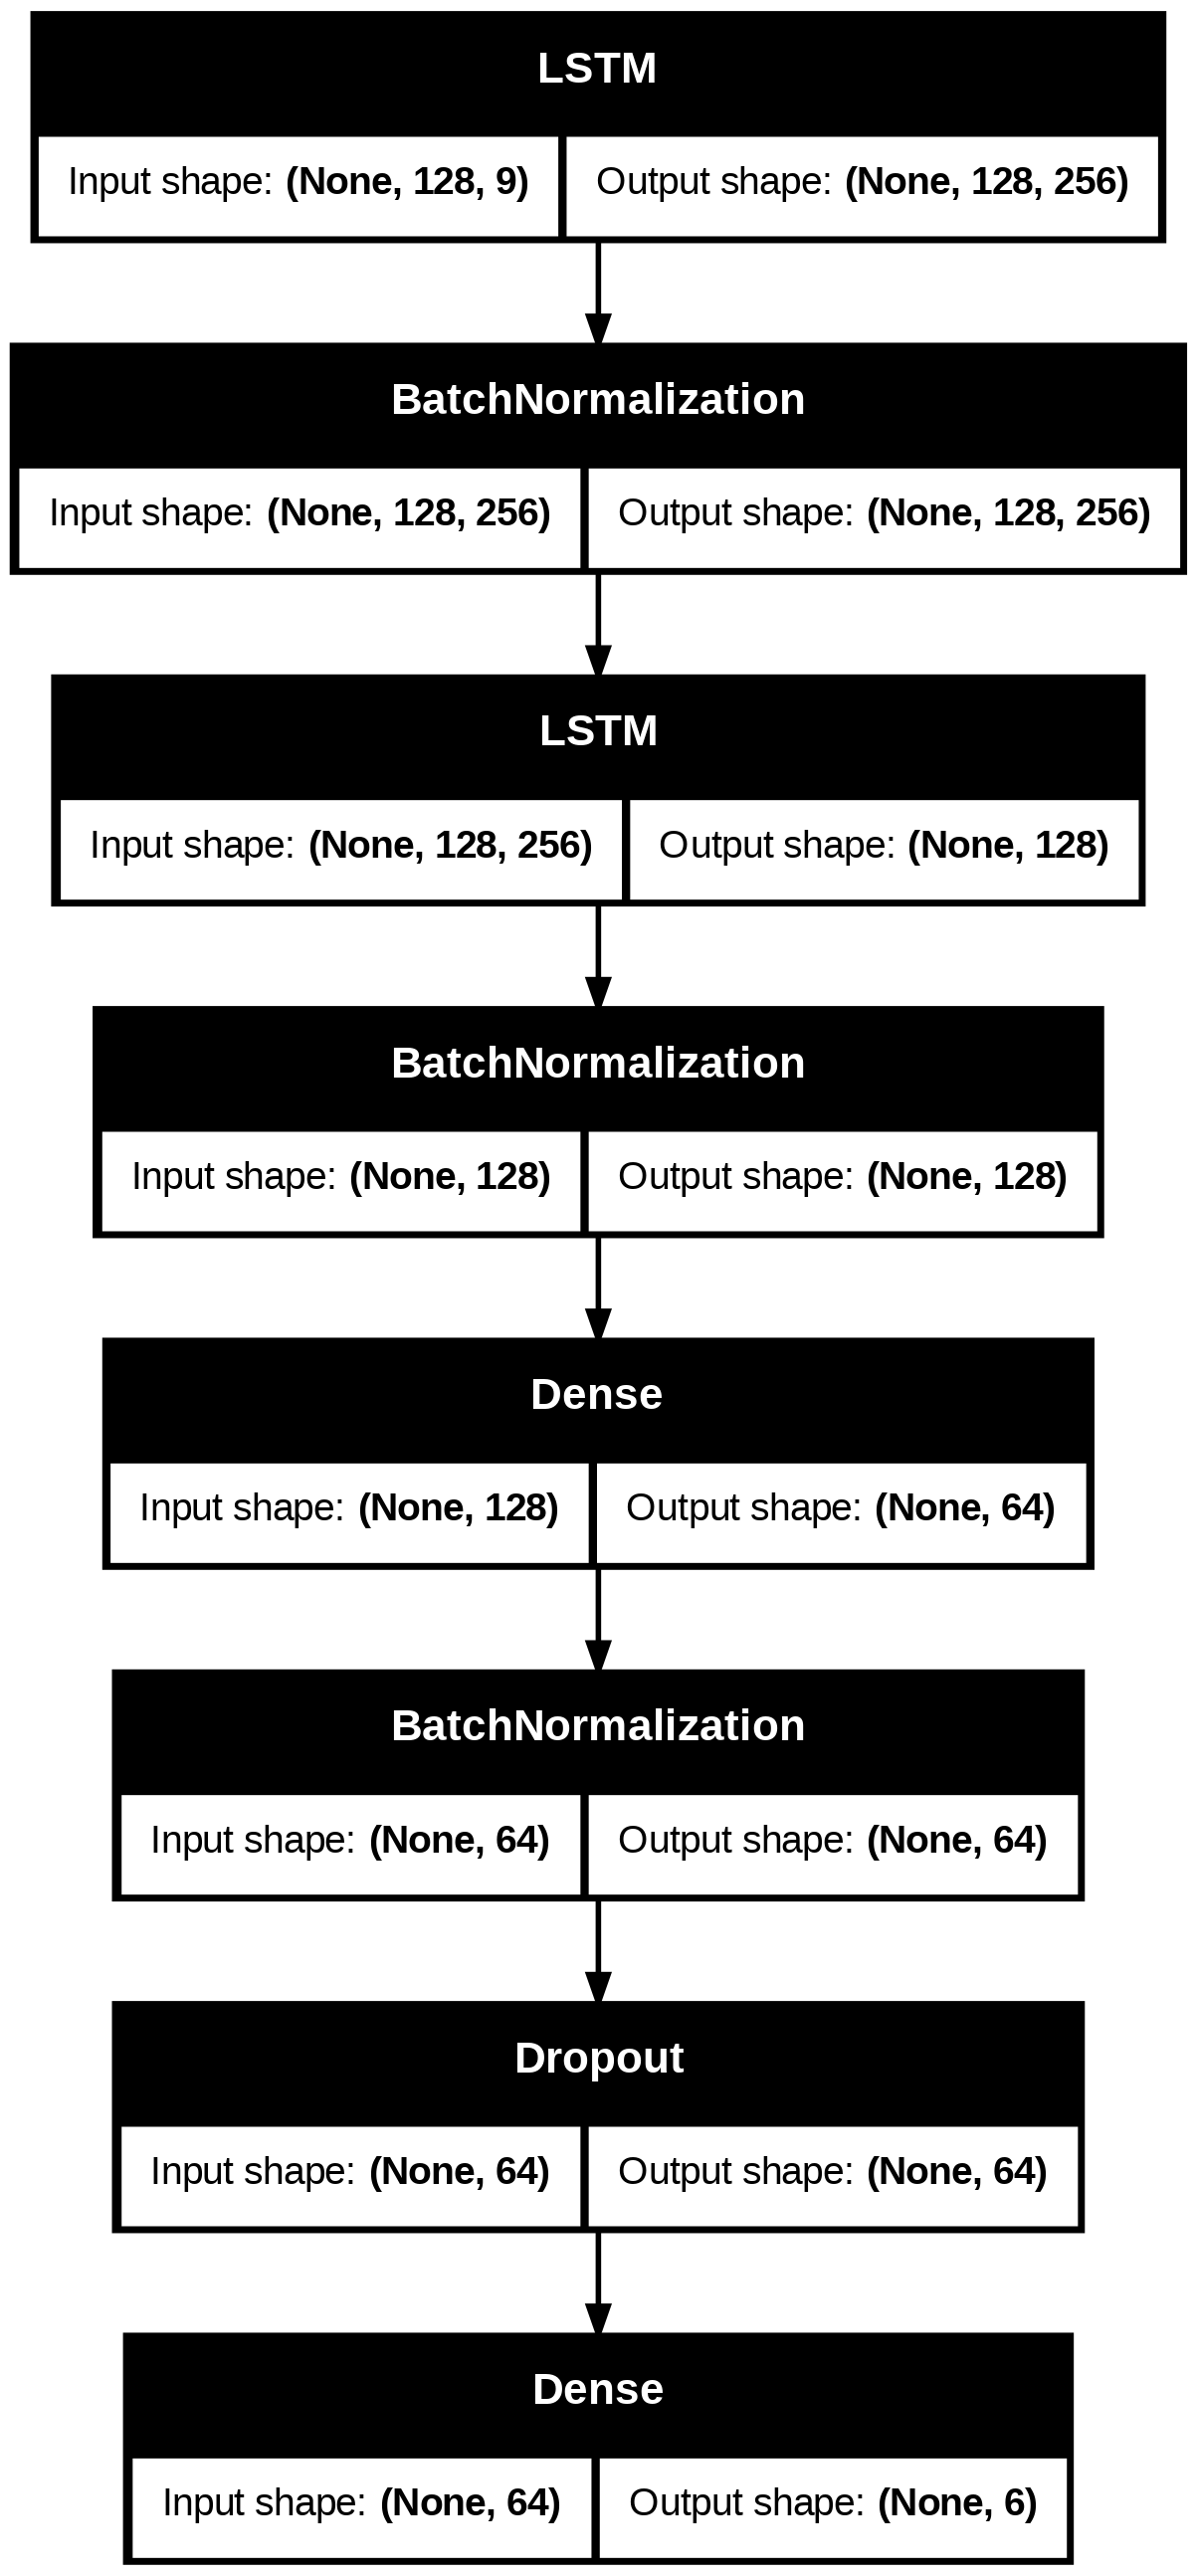

In [7]:
tf.keras.utils.plot_model(model, show_shapes=True)

# callbacks

In [8]:
callbacks = [
            ModelCheckpoint(
                "UCI_HAR_LSTM_best.keras",
                save_best_only=True,
                monitor="val_sparse_categorical_accuracy",
                mode='max',
                verbose=1
            ),
            EarlyStopping(
                monitor="val_sparse_categorical_accuracy",
                patience=35,
                verbose=1,
                mode='max',
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',    # val_loss 값을 지켜보다가
                factor=0.2,            # 학습에 발전이 없으면 LR에 0.2를 곱함 (기존의 1/5 수준으로 감소)
                patience=10,           # 10번 epochs 동안 성적이 안 오르면 실행
                min_lr=0.00001,        # 최소 LR 지정
                verbose=1              # LR이 바뀔 때 화면에 메시지 출력
            )
        ]

# 모델 학습

In [9]:
history = model.fit(
            X_train, y_train,
            epochs=200,
            batch_size=32,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )

Epoch 1/200
181/184 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.0736 - sparse_categorical_accuracy: 0.6094
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.51122, saving model to UCI_HAR_LSTM_best.keras

Epoch 1: finished saving model to UCI_HAR_LSTM_best.keras
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.7755 - sparse_categorical_accuracy: 0.7172 - val_loss: 1.6930 - val_sparse_categorical_accuracy: 0.5112 - learning_rate: 0.0010
Epoch 2/200
183/184 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.3586 - sparse_categorical_accuracy: 0.8701
Epoch 2: val_sparse_categorical_accuracy improved from 0.51122 to 0.74711, saving model to UCI_HAR_LSTM_best.keras

Epoch 2: finished saving model to UCI_HAR_LSTM_best.keras
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.3174 - sparse_categorical_accuracy: 0.8854 - val_loss: 0.8226 - val_sparse_categorical_accuracy: 0.7471 - learning_rate: 0.0010
Epoch 3/200
181/184 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2237 - sparse_ca

# 모델 평가

In [10]:
# best 기록 확인
model = tf.keras.models.load_model("UCI_HAR_LSTM_best.keras")

train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 95.77%
Training loss: 0.1118
Test accuracy: 91.82%
Test loss: 0.2867


In [11]:
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# 분류 리포트
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9874    0.9456    0.9660       496
           1     0.9932    0.9363    0.9639       471
           2     0.8917    1.0000    0.9428       420
           3     0.7939    0.8473    0.8197       491
           4     0.8943    0.7951    0.8418       532
           5     0.9589    1.0000    0.9790       537

    accuracy                         0.9182      2947
   macro avg     0.9199    0.9207    0.9189      2947
weighted avg     0.9205    0.9182    0.9179      2947



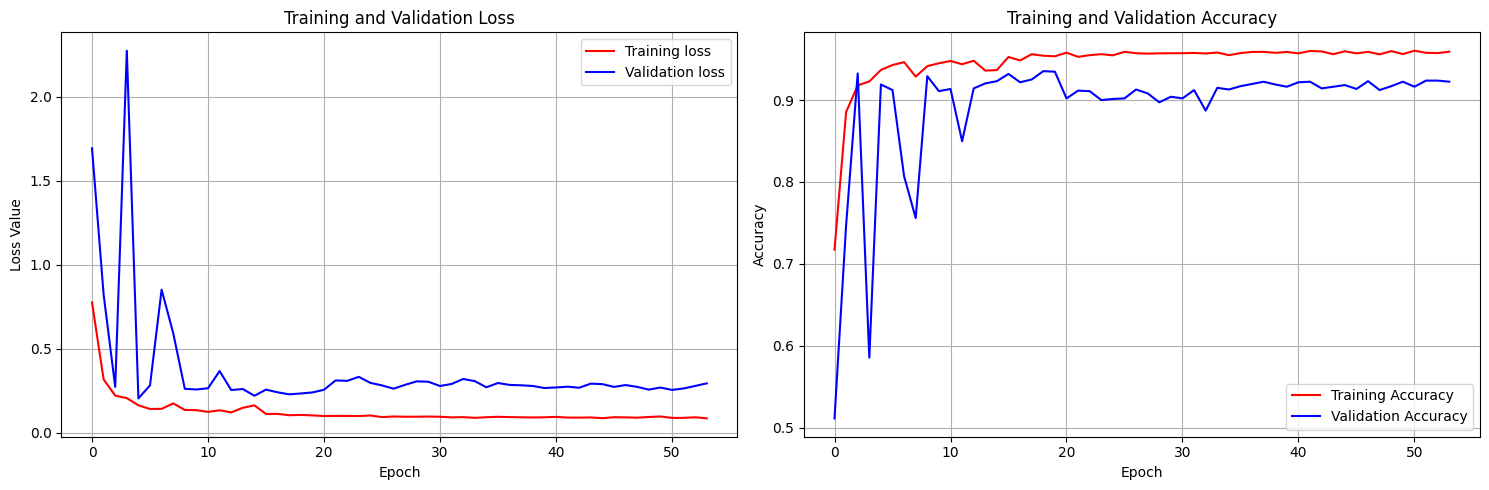

In [13]:
# loss / accuracy 그래프
train_loss = history.history['loss']
train_accuracy = history.history['sparse_categorical_accuracy']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

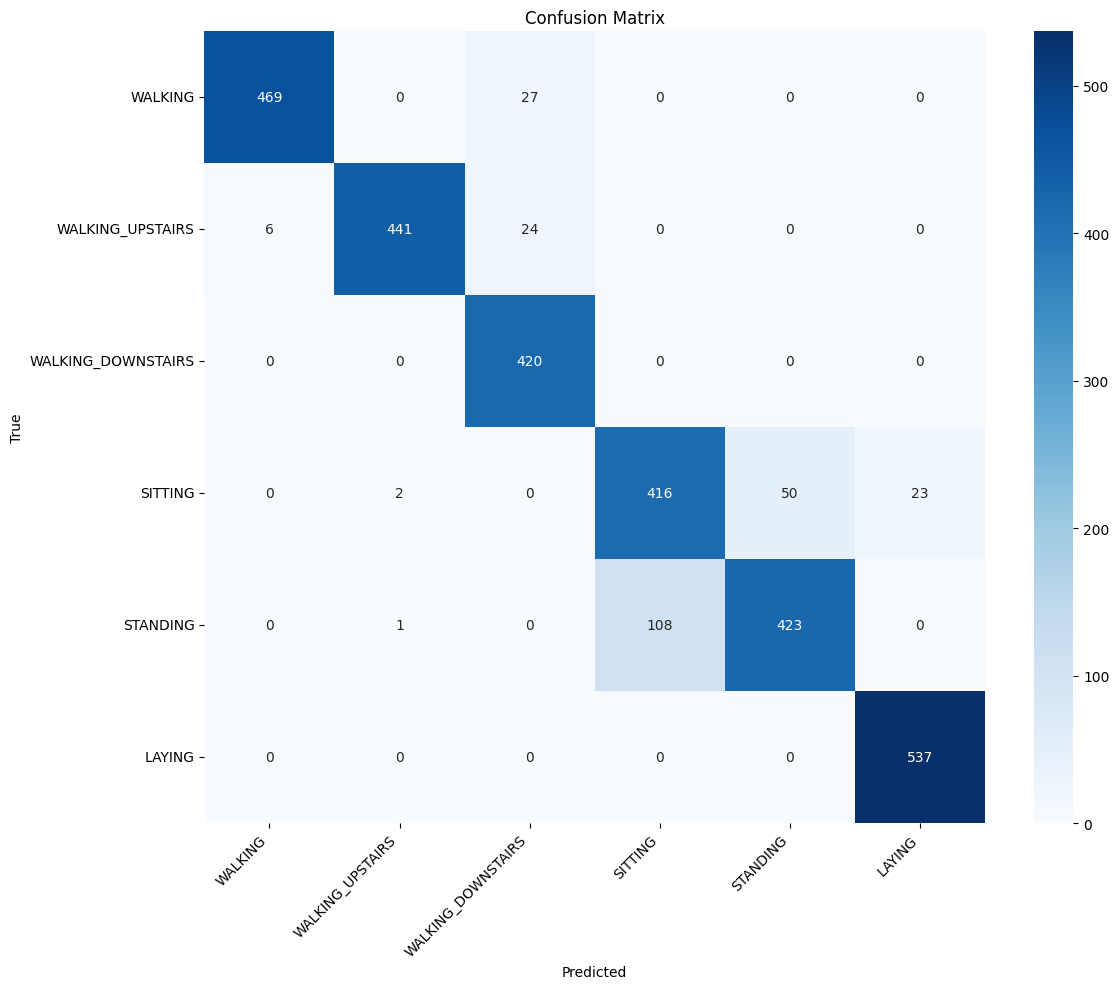

In [14]:
# 히트맵
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()